# ML «Тортилла» 



## Описание проекта
Разработка модели машинного обучения для определения массы особи черепахи по исходным данным

## Описание данных  
•	id — идентификатор измерения.  
•	binomial_name — международное научное название вида черепахи.  
•	registration_number — регистрационный номер черепахи.  
•	shell_length — длина панциря, мм.  
•	shell_width — ширина панциря, мм.  
•	head_length — длина головы, мм.  
•	head_width — ширина головы, мм.  
•	flipper_length_n — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.  
•	flipper_width_n — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.  
•	circle_count — количество колец роста на панцире черепахи.  
•	measure_count — количество измерений, которые произвели, прежде чем усреднить показатели черепахи и добавить их в таблицу.  
•	shell_crack — наличие трещин панциря.  
•	timestamp — время внесения данных о черепахе.  
•	weight — масса черепахи, кг.  


## Постановка задачи машинного обучения

Тип решаемой задачи: регрессия  
Целевая переменная: масса особи черепахи  
Метрики качества модели: MAE (основная), MSE, MAPE, R2
Успешной считается наилучшая модель по метрикам валидационной выборки, с метрикой MAE <=5 по результатам предсказаний на тестовой выборке и R2>=0.97

#### Подключение требуемых библиотек

In [1]:
!pip install -U scikit-learn phik -q


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.linear_model import SGDRegressor, LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.dummy import DummyRegressor


import phik
from phik import phik_matrix




### Загрузка датасета

#### Загрука и вывод датасета

In [2]:
df=pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',')
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


## Исследовательский анализ данных

#### Вывод переченя уникальных видов черепах

In [3]:
df['binomial_name']=df['binomial_name'].str.lower() # нормализуем названия черепах для единообразия
df['binomial_name'].value_counts()

lepidochelys olivacea     4215
chelonia mydas            2829
caretta caretta            847
dermochelys coriacea       484
eretmochelys imbricata     409
lepidochelys kempii         28
Name: binomial_name, dtype: int64

#### Формирование датасета для вида chelonia mydas (суповая черепаха)

In [4]:
df_cm=df.copy() # создаем копию исходного датасета
t_name='chelonia mydas'
df_cm=df_cm[df_cm['binomial_name']==t_name] # создаем копию исходного датасета
df_cm=df_cm.reset_index(drop=True) # приводим индексы в порядок
df_cm.head()  # тестовый вывод

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
1,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074
2,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695
3,20656,chelonia mydas,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,3.0,1.0,1705325532,51.182
4,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707


#### Вывод информации о датасете

In [5]:
df_cm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2829 entries, 0 to 2828
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   object 
 2   registration number  2825 non-null   object 
 3   shell_length         2794 non-null   float64
 4   shell_width          2829 non-null   int64  
 5   head_length          2790 non-null   float64
 6   head_width           2790 non-null   float64
 7   flipper_length_1     2829 non-null   int64  
 8   flipper_width_1      2829 non-null   int64  
 9   flipper_length_2     2829 non-null   int64  
 10  flipper_width_2      2829 non-null   int64  
 11  flipper_length_3     2798 non-null   float64
 12  flipper_width_3      2798 non-null   float64
 13  flipper_length_4     2798 non-null   float64
 14  flipper_width_4      2798 non-null   float64
 15  circle_count         2829 non-null   i

Выделение признаков, применяемых для обучения модели будет проводиться после определения степени корреляции различных измерений

В датасете 20 столбцов и 2829 строк.  
Завышена размерность типов данных int и float в столбцах.  
Присутствуют пропуски.  
Названия стролбцов соответствуют формату snake_case.

#### Проверка на дубликаты (явные)

In [6]:
df_cm.duplicated().sum()

341

В датасете присутствуют дубликаты.  

#### Удаление дубликатов

In [7]:
df_cm=df_cm.drop_duplicates()
# df_cm.info()

#### Вывод информации о пропусках в датасете

In [8]:
missing_data=pd.DataFrame({'Пропуски, шт.':df_cm.isna().sum(), 'Доля пропусков, %':(df_cm.isna().mean()*100).round(2), 'Заполнено, шт.':df_cm.count()}).sort_values(by='Доля пропусков, %', ascending=False)
print(missing_data)

                     Пропуски, шт.  Доля пропусков, %  Заполнено, шт.
shell_crack                   1889              75.92             599
measure_count                   72               2.89            2416
head_length                     35               1.41            2453
head_width                      35               1.41            2453
flipper_length_4                29               1.17            2459
shell_length                    29               1.17            2459
flipper_width_4                 29               1.17            2459
flipper_length_3                29               1.17            2459
flipper_width_3                 29               1.17            2459
registration number              4               0.16            2484
weight                           2               0.08            2486
timestamp                        0               0.00            2488
circle_count                     0               0.00            2488
id                  



Удаляем строки с пропусками в столбцах:
'head_width','head_length','flipper_length_4','flipper_width_4','flipper_length_3','flipper_width_3','shell_length', 'weight'  
shell_crack, measure_count оставляем, т.к. доля пропусков в этих столбцах в общем объеме высока

In [9]:

drop_list=['head_width','head_length','flipper_length_4','flipper_width_4','flipper_length_3','flipper_width_3','shell_length', 'weight']
df_clear=df_cm.dropna(subset=drop_list).copy()
(df_cm.shape[0]-df_clear.shape[0])/df_cm.shape[0]*100


3.697749196141479

После удаления пропусков "ушло" 3.7 % датасета, что допустимо

#### Анализ распределения признаков, представленных в датасете

#### Вывод разброса по ширине и длине панциря

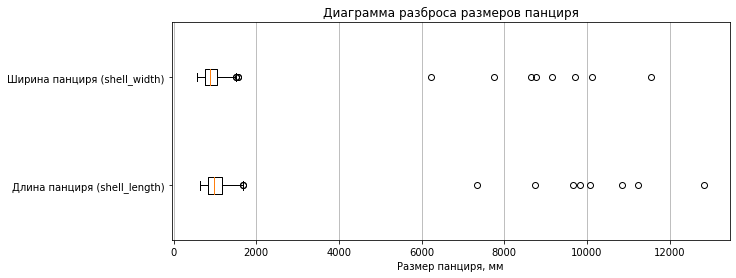

In [10]:
plt.figure(figsize=(10,4))
t_value_data_large = [df_clear['shell_length'], df_clear['shell_width']]
plt.boxplot(t_value_data_large, vert=False)
plt.title('Диаграмма разброса размеров панциря')
plt.xlabel('Размер панциря, мм')
plt.grid(axis='x')
plt.yticks([1, 2], ['Длина панциря (shell_length)', 'Ширина панциря (shell_width)'])
plt.show()

Присутствует значительное количество выбросов.  
Отдельного внимания заслушивает группа выбросов с большими значениями

Важно.  Распределение значений габаритов панциря:
- имеет значительный промежуток между максимальным допустимым значением и облаком выбросов справа
- все выбросы собраны в зоне превышения максимальных стат значений размеров панциря  
- распределение значений выбросов по каждому из 2 показателей (ширина, длина) строго упорядочены и близки по форме распределения  
Это наряду с информацией об ошибках статиста при занесении информации о размерах (*10) может говорить, о том, мы имеем дело именно с такими значениями и "выбросы" могут быть преобразованы в корректные значения  

#### Преобразование выбросов-ошибок статиста.  
Все значения габаритов панциря выше 6000 уменьшаем в 10 раз   

In [11]:
lim_size=6000
df_clear['shell_length'] = df_clear['shell_length'].where(df_clear['shell_length'] < lim_size, df_clear['shell_length'] / 10)
df_clear['shell_width'] = df_clear['shell_width'].where(df_clear['shell_width'] < lim_size, df_clear['shell_width'] / 10)

#### Визуальное представление разброса показателей габаритов головы и ласт

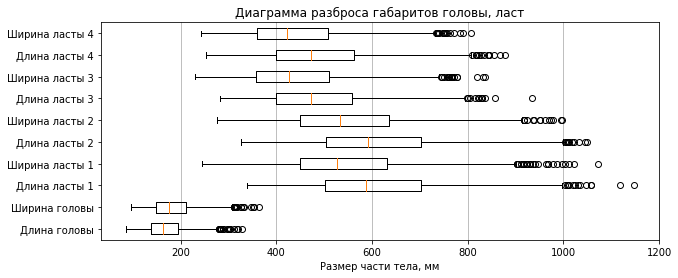

In [12]:
plt.figure(figsize=(10,4))
t_value_data_small = [
    df_clear['head_length'],
    df_clear['head_width'],
    df_clear['flipper_length_1'],
    df_clear['flipper_width_1'],
    df_clear['flipper_length_2'],
    df_clear['flipper_width_2'],
    df_clear['flipper_length_3'],
    df_clear['flipper_width_3'],
    df_clear['flipper_length_4'], 
    df_clear['flipper_width_4']
    ]
plt.boxplot(t_value_data_small, vert=False)
plt.title('Диаграмма разброса габаритов головы, ласт')
plt.xlabel('Размер части тела, мм')
plt.grid(axis='x')
plt.yticks(
            [1, 2, 3,4,5,6,7,8,9,10], 
            [
            'Длина головы', 
            'Ширина головы',
            'Длина ласты 1',
            'Ширина ласты 1',
            'Длина ласты 2',
            'Ширина ласты 2',
            'Длина ласты 3',
            'Ширина ласты 3',
            'Длина ласты 4',
            'Ширина ласты 4'
            ]
            )
plt.show()

#### Проверка выбросов для показателя circle count

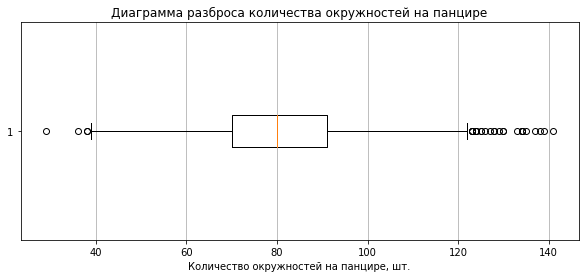

In [13]:
plt.figure(figsize=(10,4))
plt.boxplot(df_clear['circle_count'], vert=False)
plt.title('Диаграмма разброса количества окружностей на панцире')
plt.xlabel('Количество окружностей на панцире, шт.')
plt.grid(axis='x')
plt.show()

#### Вывод выбросов по значениям веса черепах

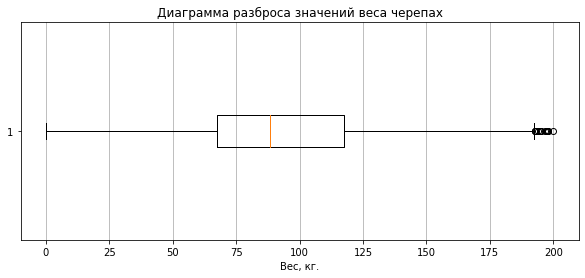

In [14]:
plt.figure(figsize=(10,4))
plt.boxplot(df_clear['weight'], vert=False)
plt.title('Диаграмма разброса значений веса черепах')
plt.xlabel('Вес, кг.')
plt.grid(axis='x')
plt.show()

#### Вывод распределения весов черепах для наглядности

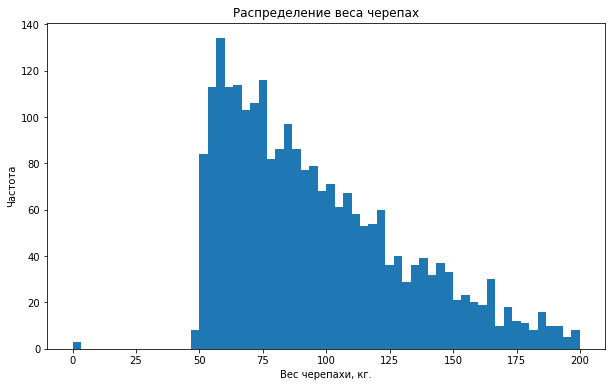

In [15]:
plt.figure(figsize=(10,6))
df_clear['weight'].plot(kind='hist', bins=60)
plt.title("Распределение веса черепах")
plt.xlabel("Вес черепахи, кг.")
plt.ylabel("Частота")
plt.show()

Визуально видны ошибки в данных. Объективно присутствуют значения веса близкие к 0, что аномально

В каждом показателе и целевой переменной присутствуют выбросы

#### Устраняем выбросы по всем показателям

In [16]:
# Функция для исключения выбросов
def over_drop(df, col_name):
    iqr=df[col_name].quantile(0.75)-df[col_name].quantile(0.25)
    high_lim=df[col_name].quantile(0.75)+1.5*iqr
    low_lim=df[col_name].quantile(0.25)-1.5*iqr
    df=df[(df[col_name]<=high_lim) & (df[col_name]>=low_lim)]
    return df

#### Удаляем выбросы

In [17]:
value_list=[
    'shell_length',
    'shell_width',
    'circle_count',
    'head_length',
    'head_width',
    'flipper_length_1',
    'flipper_width_1',
    'flipper_length_2',
    'flipper_width_2',
    'flipper_length_3',
    'flipper_width_3',
    'flipper_length_4', 
    'flipper_width_4',
    'weight'
    ]
for i in value_list:
    df_clear=over_drop(df_clear,i)
df_clear=df_clear.reset_index(drop=True)
df_clear.head()


,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
1,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074
2,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695
3,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707
4,18151,chelonia mydas,17ee6cadc77c0f418dbea1acaa998441,887.0,813,149.0,140.0,578,514,538,472,462.0,308.0,408.0,396.0,70,4.0,NaN,1679804213,75.829


#### Проверка на относительные аномалии внутри измерений габаритов ласт одной особи

In [18]:
list_flippers=[
    'flipper_length_1',
    'flipper_width_1',
    'flipper_length_2',
    'flipper_width_2',
    'flipper_length_3',
    'flipper_width_3',
    'flipper_length_4', 
    'flipper_width_4'
]
df_clear[list_flippers].describe()

,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,591.462545,530.430957,591.601534,531.675090,471.572202,425.464801,473.089350,425.909296
std,122.964655,113.351885,119.391987,113.135473,96.040902,90.961672,97.193638,89.920659
min,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000
25%,495.000000,445.000000,497.000000,444.000000,395.000000,353.000000,395.000000,356.000000
50%,573.000000,514.000000,576.000000,521.500000,459.000000,414.000000,460.000000,415.000000
75%,674.250000,606.000000,676.250000,608.000000,538.000000,488.250000,541.000000,485.250000
max,952.000000,869.000000,965.000000,873.000000,761.000000,699.000000,758.000000,685.000000


Аномании (значительные отличия среди измерений ласт не выявлены)

Выбросы из показателей исключены

#### Определение характеристик датасета после очистки (выброс, дубликаты, пропуски)

In [19]:
(df_cm.shape[0]-df_clear.shape[0])/df_cm.shape[0]
# df_clear.info()

0.10932475884244373

После очистки было удалено 11% исходного датасета, из которых около 50% пришлось на дубликаты, остальное на выбросы и пропуски

#### Вывод характеристик рабочего датасета

In [20]:
df_clear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2216 entries, 0 to 2215
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2216 non-null   int64  
 1   binomial_name        2216 non-null   object 
 2   registration number  2213 non-null   object 
 3   shell_length         2216 non-null   float64
 4   shell_width          2216 non-null   int64  
 5   head_length          2216 non-null   float64
 6   head_width           2216 non-null   float64
 7   flipper_length_1     2216 non-null   int64  
 8   flipper_width_1      2216 non-null   int64  
 9   flipper_length_2     2216 non-null   int64  
 10  flipper_width_2      2216 non-null   int64  
 11  flipper_length_3     2216 non-null   float64
 12  flipper_width_3      2216 non-null   float64
 13  flipper_length_4     2216 non-null   float64
 14  flipper_width_4      2216 non-null   float64
 15  circle_count         2216 non-null   i

#### Оптимизация типов данных

#### Ввиду последующих действий для формирования дополнительных признаков (могут требоваться значения текущей разрядности) оптимизация разрядности типов данных не проводится

#### Оценка корреляции

In [21]:
float_data=['shell_length', 'shell_width', 'head_length', 'head_width', 'measure_count', 'shell_crack', 'weight']
int_data=['id', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'timestamp']
column_data=int_data+float_data
corr_matrix=df_clear[column_data].phik_matrix(interval_cols=column_data)
print(corr_matrix.loc[corr_matrix.index!='weight']['weight'].sort_values(ascending=False))

shell_length        0.950515
shell_width         0.928162
flipper_length_1    0.866926
flipper_length_4    0.862335
flipper_length_2    0.860304
flipper_length_3    0.858968
flipper_width_2     0.837619
flipper_width_3     0.832255
flipper_width_1     0.830967
flipper_width_4     0.830260
head_length         0.811559
head_width          0.793447
shell_crack         0.558219
circle_count        0.470084
id                  0.063452
measure_count       0.053446
timestamp           0.000000
Name: weight, dtype: float64


In [22]:
# corr_matrix

#### Графическое представление корреляции

<AxesSubplot:>

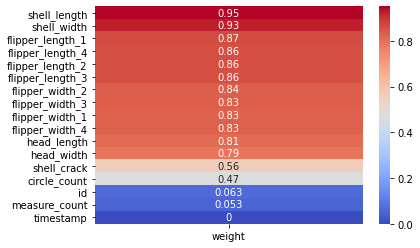

In [23]:
sns.heatmap(corr_matrix[corr_matrix.index!='weight'][['weight']].sort_values(by='weight', ascending=False), annot=True, cmap='coolwarm')

Для обучения применяются все показатели кроме:
- id, measure_count, timestamp - низкая степень корреляции
- shell_crack - значительная доля пропусков >70%

#### Исключение мультиколлинеарности.  
Габариты (длина, ширина) панциря, головы и особенно ласт (4 шт.) особи могут формировать мультиколлинеарность.
Ввиду этого, выполняется формирование новых комплексных признаков для каждого из набора измерений.  
Формируем "площадь" части тела особи (длина х ширина), а для ласт делаем усреднение по "площади" 4 ласт.

#### Формирование новых комплексных признаков на основе габаритов головы и габаритов ласт

In [24]:
# создание усредненного признака по габаритам ласт. средняя площадь одной ласты особи

df_clear['flipper_avg']=((df_clear['flipper_length_1']*df_clear['flipper_width_1']+
                            df_clear['flipper_length_2']*df_clear['flipper_width_2']+
                            df_clear['flipper_length_3']*df_clear['flipper_width_3']+
                            df_clear['flipper_length_4']*df_clear['flipper_width_4'])/4).round(2)

# создание усредненного признака по габаритам головы. средняя площадь головы особи
df_clear['head_avg']=(df_clear['head_length']*df_clear['head_width']).round(2)
df_clear['shell_avg']=(df_clear['shell_length']*df_clear['shell_width'])
# проверяем результат
df_clear.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,...,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight,flipper_avg,head_avg,shell_avg
0,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,...,311.0,325.0,66,4.0,1.0,1751228603,56.352,152324.00,17346.0,483784.0
1,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318,207.0,248.0,845,704,661,...,661.0,585.0,111,2.0,5.0,1699913950,154.074,472973.75,51336.0,1760848.0
2,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926,216.0,156.0,562,488,529,...,553.0,463.0,76,1.0,NaN,1680303901,87.695,240375.25,33696.0,935260.0
3,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940,187.0,157.0,518,557,545,...,541.0,479.0,103,2.0,NaN,1707227368,92.707,263491.75,29359.0,923080.0
4,18151,chelonia mydas,17ee6cadc77c0f418dbea1acaa998441,887.0,813,149.0,140.0,578,514,538,...,408.0,396.0,70,4.0,NaN,1679804213,75.829,213723.00,20860.0,721131.0


#### Создание матрицы корреляции с учетом новых признаков

In [25]:
column_data_2=column_data+['head_avg', 'flipper_avg', 'shell_avg']
corr_mtrx_2=df_clear[column_data_2].phik_matrix(interval_cols=column_data_2)
display_mtrx=corr_mtrx_2.loc[corr_mtrx_2.index!='weight', ['weight']].sort_values(by='weight', ascending=False)
display_mtrx

,weight
shell_avg,0.960846
flipper_avg,0.953715
shell_length,0.950515
shell_width,0.928162
flipper_length_1,0.866926
head_avg,0.863387
flipper_length_4,0.862335
flipper_length_2,0.860304
flipper_length_3,0.858968
flipper_width_2,0.837619


#### Построение тепловой карты c новыми признаками

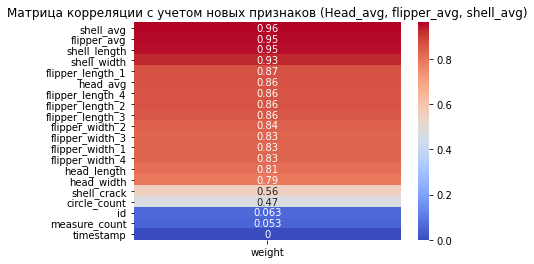

In [26]:
sns.heatmap(display_mtrx, cmap='coolwarm', annot=True)
plt.title('Матрица корреляции с учетом новых признаков (Head_avg, flipper_avg, shell_avg)');

Степень корреляции комплексных признаков по габаритам головы, ласт и панциря выше  (в некоторых случаях значительно) корреляции признаков габаритов частей тела поотдельности.  
Ввиду этого и для устранения мультиколлинеарности новые признаки будут использованы для обучения модели

#### Формирование и фиксация итогового датасета для разработки модели

In [27]:
lr_ftrs=['shell_avg',
'head_avg',
'flipper_avg',
'circle_count',
'weight'    
]
df_lr=df_clear[lr_ftrs].copy()
df_lr

,shell_avg,head_avg,flipper_avg,circle_count,weight
0,483784.0,17346.0,152324.00,66,56.352
1,1760848.0,51336.0,472973.75,111,154.074
2,935260.0,33696.0,240375.25,76,87.695
3,923080.0,29359.0,263491.75,103,92.707
4,721131.0,20860.0,213723.00,70,75.829
...,...,...,...,...,...
2211,548298.0,14241.0,143950.00,60,57.859
2212,641440.0,22125.0,195699.75,83,69.706
2213,595029.0,24420.0,181390.50,55,67.719
2214,1253410.0,57120.0,340382.50,115,121.688


Подготовлен датасет для обучения модели

### Предобработка данных

#### Формирование исходных данных (признаки\целевая переменная)

In [28]:
y=df_lr['weight'].copy()
X=df_lr.drop('weight', axis=1).copy()

Разделение данных не выборки: обучающая, валидационная, тестовая (60\20\20)

In [29]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=43, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=43, shuffle=True)
X_train=X_train.copy()
X_val=X_val.copy()
X_test=X_test.copy()
y_train=y_train.copy()
y_val=y_val.copy()
y_test=y_test.copy()

Разбивка на выборки выполнена

#### Масштабирование признаков

In [30]:
# Функция для масштабирования
def std_scale(X_train, X_val, X_test):
    X_tr=X_train.copy()
    X_vl=X_val.copy()
    X_tst=X_test.copy()
    for i in X_tr.columns:
        std_train=X_tr[i].std()
        mean_train=X_tr[i].mean()
        X_tr[i]=(X_tr[i]-mean_train)/std_train
        X_vl[i]=(X_vl[i]-mean_train)/std_train
        X_tst[i]=(X_tst[i]-mean_train)/std_train
    return X_tr, X_vl, X_tst
# Функция для нормализации
def norm_scale(X_train, X_val, X_test):
    X_tr=X_train.copy()
    X_vl=X_val.copy()
    X_tst=X_test.copy()
    for i in X_tr.columns:
        min_train=X_tr[i].min()
        max_train=X_tr[i].max()
        X_tr[i]=(X_tr[i]-min_train)/(max_train-min_train)
        X_vl[i]=(X_vl[i]-min_train)/(max_train-min_train)
        X_tst[i]=(X_tst[i]-min_train)/(max_train-min_train)
    return X_tr, X_vl, X_tst


#### Подготовка датасетов с вариациями по масштабированию.  
Отсутствуют\стандартизация\нормализация

In [31]:
X_train_std, X_val_std, X_test_std=std_scale(X_train, X_val, X_test) # масштабирование стандартизацией
X_train_nrm, X_val_nrm, X_test_nrm=norm_scale(X_train, X_val, X_test) # масштабирование нормализацией

## Обучение моделей

#### Создание комплексного цикла обучения\метрик различных моделей, различных параметров, различных датасетов

In [32]:
df_result_list=[]
# имена обучающих датасетов
df_nms_list=[
    'n_scaled',
    'std_scaled',
    'nrm_scaled'
    ]
# список обучающих датасетов
df_rg_tr_list=[
    X_train,
    X_train_std,
    X_train_nrm    
    ]
# список валидационных датасетов
df_rg_vl_list=[
    X_val,
    X_val_std,
    X_val_nrm    
    ]
# список моделей
model_list=[
    'lr_model',
    'l1_model',
    'l2_model',
    'sg_model'
    ]
# список параметров
# для Lasso и Ridge
a_list=np.logspace(-3, 10, 14)
# Для SGD
max_iter_list=np.logspace(2, 6, 5).astype(int)
eta_list=np.logspace(-5, 2, 8)
# список функций потерь. для наглядности используем 2.
loss_list=[
    'squared_error',
    'huber'
    ]
# Циклы создания, обучения, проверки моделей на валидационных данных
for df_nms, df_rg_tr, df_rg_vl in zip (df_nms_list, df_rg_tr_list, df_rg_vl_list):
    for model in model_list:
        if model == 'lr_model':
            lr_model=LinearRegression()
            lr_model.fit(df_rg_tr, y_train)
            lr_model_pr=lr_model.predict(df_rg_vl)
            # метрики
            mae=mean_absolute_error(y_val, lr_model_pr)
            mse=mean_squared_error(y_val, lr_model_pr)
            mape=mean_absolute_percentage_error(y_val, lr_model_pr)
            r2=r2_score(y_val, lr_model_pr)
            df_row={
                'model': 'lr_model',
                'dset': df_nms,
                'mae':mae,
                'mse':mse,
                'mape':mape,
                'r2':r2
                }
            df_result_list.append(df_row)
        elif model == 'l1_model':
            for alpha_coeff in a_list:
                l1_model=Lasso(alpha=alpha_coeff, random_state=43)
                l1_model.fit(df_rg_tr, y_train)
                l1_model_pr=l1_model.predict(df_rg_vl)
                # метрики
                mae=mean_absolute_error(y_val, l1_model_pr)
                mse=mean_squared_error(y_val, l1_model_pr)
                mape=mean_absolute_percentage_error(y_val, l1_model_pr)
                r2=r2_score(y_val, l1_model_pr)
                df_row={
                    'model':'l1_model',
                    'dset':df_nms,
                    'mae':mae,
                    'mse':mse,
                    'mape':mape,
                    'r2':r2,
                    'alpha':alpha_coeff
                    }
                df_result_list.append(df_row)
        elif model == 'l2_model':
            for alpha_coeff in a_list:
                l2_model=Ridge(alpha=alpha_coeff, random_state=43)
                l2_model.fit(df_rg_tr, y_train)
                l2_model_pr=l2_model.predict(df_rg_vl)
                # метрики
                mae=mean_absolute_error(y_val, l2_model_pr)
                mse=mean_squared_error(y_val, l2_model_pr)
                mape=mean_absolute_percentage_error(y_val, l2_model_pr)
                r2=r2_score(y_val, l2_model_pr)
                df_row={
                    'model': 'l2_model',
                    'dset': df_nms,
                    'mae':mae,
                    'mse':mse,
                    'mape':mape,
                    'r2':r2,
                    'alpha':alpha_coeff
                    }
                df_result_list.append(df_row)
        elif model == 'sg_model' :
            for l_list in loss_list:    
                for max_it in max_iter_list:
                    for eta in eta_list:
                        sg_model=SGDRegressor(eta0=eta, max_iter=max_it, loss=l_list, random_state=43)
                        sg_model.fit(df_rg_tr, y_train)
                        sg_model_pr=sg_model.predict(df_rg_vl)
                        # метрики
                        mae=mean_absolute_error(y_val, sg_model_pr)
                        mse=mean_squared_error(y_val, sg_model_pr)
                        mape=mean_absolute_percentage_error(y_val, sg_model_pr)
                        r2=r2_score(y_val, sg_model_pr)
                        df_row={
                            'model': 'sg_model',
                            'dset': df_nms,
                            'mae':mae,
                            'mse':mse,
                            'mape':mape,
                            'r2':r2,
                            'max_iter':max_it,
                            'eta0':eta,
                            'loss':l_list
                            }
                        df_result_list.append(df_row)
# создание dummy модели
dm_model=DummyRegressor()
dm_model.fit(X_train, y_train)
dm_model_pr=dm_model.predict(X_val)
# метрики
d_mae=mean_absolute_error(y_val, dm_model_pr)
d_mse=mean_squared_error(y_val, dm_model_pr)
d_mape=mean_absolute_percentage_error(y_val, dm_model_pr)
d_r2=r2_score(y_val, dm_model_pr)
df_row={
'model':'dummy',
'dset':'n_scaled',
'mae':d_mae,
'mse':d_mse,
'mape':d_mape,
'r2':d_r2,
}
df_result_list.append(df_row)
# сборка общего датасета
df_models=pd.DataFrame(df_result_list)

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_

#### Сортировка итогового датасета по показателю MAE, определенного ключевым при оценке качества модели

In [33]:
df_model_rating=df_models.sort_values(by=['mae', 'max_iter']).reset_index(drop=True) # по mae и оптимальным параметрам
df_model_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   model     328 non-null    object 
 1   dset      328 non-null    object 
 2   mae       328 non-null    float64
 3   mse       328 non-null    float64
 4   mape      328 non-null    float64
 5   r2        328 non-null    float64
 6   alpha     84 non-null     float64
 7   max_iter  240 non-null    float64
 8   eta0      240 non-null    float64
 9   loss      240 non-null    object 
dtypes: float64(7), object(3)
memory usage: 25.8+ KB


Сформирован датасет, учитывающий различные варианты моделей, обучающих датасетов, гиперпараметров моделей.  
Выполнена сортировка моделей по показателю MAE.

#### Вывод ТОП-10 моделей\параметров

In [34]:
df_model_rating.head(20)

,model,dset,mae,mse,mape,r2,alpha,max_iter,eta0,loss
0,sg_model,std_scaled,2.761740,12.472995,0.030964,0.984760,NaN,100.0,10.0,huber
1,sg_model,std_scaled,2.761740,12.472995,0.030964,0.984760,NaN,1000.0,10.0,huber
2,sg_model,std_scaled,2.761740,12.472995,0.030964,0.984760,NaN,10000.0,10.0,huber
3,sg_model,std_scaled,2.761740,12.472995,0.030964,0.984760,NaN,100000.0,10.0,huber
4,sg_model,std_scaled,2.761740,12.472995,0.030964,0.984760,NaN,1000000.0,10.0,huber
5,l1_model,n_scaled,2.776828,12.373093,0.031452,0.984882,1.000,NaN,NaN,NaN
6,l2_model,n_scaled,2.776869,12.370531,0.031452,0.984885,100000.000,NaN,NaN,NaN
7,l2_model,n_scaled,2.777041,12.363482,0.031454,0.984893,10000.000,NaN,NaN,NaN
8,l1_model,n_scaled,2.777051,12.363405,0.031454,0.984894,0.100,NaN,NaN,NaN
9,l2_model,n_scaled,2.777125,12.362940,0.031455,0.984894,1000.000,NaN,NaN,NaN


Сформирован рейтинг моделей.  
В рамках первых 10 отличия по метрикам незначительны.  
Наиболее эффективна модель SGD (стохастический градиентный спуск) c выполненным методом стандартизации масштабированием количеством итераций 100 и шагом 0.1.  MAE 2.76, R2=0.98  
Указанные показатели соответствуют требованиям ТЗ проекта (mse<5, r2>0.97)
Примечательно, что с меньшим количеством шагов модель достигла тех же результатов!  
Эти данные будут переданы в модель - лидер.

## Сравнение моделей на валидационной выборке

## Проверка лучшей модели на тестовой выборке

#### Выполняем проверку лучшей модели на тестовой выборке

In [35]:
# Создаем модель с параметрами лучшей

# словарь для соотнесения названий и видов учебных датасетов (с учетом масштабирования)
dset_names={'n_scaled':X_train, 'std_scaled':X_train_std, 'nrm_scaled':X_train_nrm}  
# словарь для соотнесения названий и видов тестовых датасетов (с учетом масштабирования)
test_dset_names={'n_scaled':X_test,'std_scaled': X_test_std,'nrm_scaled': X_test_nrm}

if df_model_rating.loc[0, 'model']=='lr_model':
    ldr_model=LinearRegression()
    ldr_model.fit(dset_names[df_model_rating.loc[0, 'dset']], y_train)
    ldr_model_pr=ldr_model.predict(test_dset_names[df_model_rating.loc[0,'dset']])
    # метрики
    mae=mean_absolute_error(y_test, ldr_model_pr)
    mse=mean_squared_error(y_test, ldr_model_pr)
    mape=mean_absolute_percentage_error(y_test, ldr_model_pr)
    r2=r2_score(y_test, ldr_model_pr)
    print('Model name: lr_model')
    best_model=ldr_model
elif df_model_rating.loc[0, 'model']=='l1_model':
    ldr_l1_model=Lasso(alpha=df_model_rating.loc[0,'alpha'], random_state=43)
    ldr_l1_model.fit(dset_names[df_model_rating.loc[0, 'dset']], y_train)
    ldr_l1_model_pr=ldr_l1_model.predict(test_dset_names[df_model_rating.loc[0,'dset']])
    # метрики
    mae=mean_absolute_error(y_test, ldr_l1_model_pr)
    mse=mean_squared_error(y_test, ldr_l1_model_pr)
    mape=mean_absolute_percentage_error(y_test, ldr_l1_model_pr)
    r2=r2_score(y_test, ldr_l1_model_pr)
    best_model=ldr_l1_model
    print('Model name: l1_model')
elif df_model_rating.loc[0, 'model']=='l2_model':
    ldr_l2_model=Ridge(alpha=df_model_rating.loc[0,'alpha'], random_state=43)
    ldr_l2_model.fit(dset_names[df_model_rating.loc[0, 'dset']], y_train)
    ldr_l2_model_pr=ldr_l2_model.predict(test_dset_names[df_model_rating.loc[0,'dset']])
    # метрики
    mae=mean_absolute_error(y_test, ldr_l2_model_pr)
    mse=mean_squared_error(y_test, ldr_l2_model_pr)
    mape=mean_absolute_percentage_error(y_test, ldr_l2_model_pr)
    r2=r2_score(y_test, ldr_l2_model_pr)
    print('Model name: l2_model')
    best_model=ldr_l2_model
elif df_model_rating.loc[0, 'model']=='sg_model':
    ldr_sg_model=SGDRegressor(eta0=df_model_rating.loc[0,'eta0'], max_iter=df_model_rating.loc[0,'max_iter'].astype(int), loss=df_model_rating.loc[0,'loss'], random_state=43)
    ldr_sg_model.fit(dset_names[df_model_rating.loc[0, 'dset']], y_train)
    ldr_sg_model_pr=ldr_sg_model.predict(test_dset_names[df_model_rating.loc[0,'dset']])
    # метрики
    mae=mean_absolute_error(y_test, ldr_sg_model_pr)
    mse=mean_squared_error(y_test, ldr_sg_model_pr)
    mape=mean_absolute_percentage_error(y_test, ldr_sg_model_pr)
    r2=r2_score(y_test, ldr_sg_model_pr)
    best_model=ldr_sg_model
    print('Model name: sgd_model')

print('MAE:', mae)
print('MSE:', mse)
print('MAPE:', mape)
print('R2:', r2)


Model name: sgd_model
MAE: 2.8949609714684836
MSE: 13.821053657325875
MAPE: 0.03131334686999586
R2: 0.9826721649925123


Значения метрик на тестовой выборке минимально снизились по сравнению с валидационной

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

#### Вывод таблицы коэффициентов

In [36]:
weights = best_model.coef_
intercept = best_model.intercept_

features_wight=pd.DataFrame({
    'feature':lr_ftrs[:-1], 'weight':weights, 'abs_weight': np.abs(weights)
    }).sort_values(by='weight', ascending=False)
print('Начальное отклонение:', intercept)
features_wight

Начальное отклонение: [90.37880422]


,feature,weight,abs_weight
0,shell_avg,14.738500,14.738500
2,flipper_avg,11.641410,11.641410
1,head_avg,2.844699,2.844699
3,circle_count,0.537252,0.537252


Наиболее существенными признаками влияющими на вес особи являются габариты панциря (комплексный признак) и усредненные габариты одной ласты.  
Габариты головы черепахи влияют незначительно.  
Количество кругов на панцире имеет мизерное влияние.  
Выводы выглядят логично. Панцирь наиболее значимая часть, ласты менее, но оказывающая значимый вклад. Голова составляет незначительную долю от общего веса черепахи (научные источники).

#### Написание функции расчета веса черепахи

In [37]:
def t_weight(shell_avg, head_avg, flipper_avg, circle_count):
    f_list_names=['shell_avg', 'head_avg', 'flipper_avg', 'circle_count']
    f_list_val=[shell_avg, head_avg, flipper_avg, circle_count]
    f_list_scaled=[]
    for i, j in zip(f_list_names, f_list_val):
        std_train=X_train[i].std()
        mean_train=X_train[i].mean()
        i_std=(j-mean_train)/std_train
        f_list_scaled.append(i_std)
    weight=0
    for coeff, feat in zip(best_model.coef_, f_list_scaled):
        coeff_feat=coeff*feat
        weight=weight + coeff_feat
    weight=weight+best_model.intercept_
    return weight


### Общие выводы:  


1. В рамках проекта были изучены четыре линейные модели регрессии:
- LinearRegression,
- Lasso (L1-регуляризация),
- Ridge (L2-регуляризация),
- SGDRegressor.

2. Для каждой модели были рассмотрены три варианта подготовки признаков:
- без масштабирования,
- со стандартизацией,
- с нормализацией.

Дополнительно для снижения мультиколлинеарности и повышения информативности были сформированы агрегированные признаки:
- shell_avg,
- head_avg,
- flipper_avg.

3. По результатам сравнения моделей на валидационной выборке наилучший результат показала модель SGDRegressor на стандартизированных признаках.

Метрики лучшей модели на валидационной выборке:
- MAE = 2.76,
- MAPE = 0.031,
- R² = 0.985.

Метрики той же модели на тестовой выборке:
- MAE = 2.89,
- MAPE = 0.031,
- R² = 0.983.

4. Полученные результаты соответствуют требованиям заказчика:
- ошибка MAE значительно ниже допустимого порога 5 кг,
- значение R² на валидационной и тестовой выборках превышает 0.97,
- относительная ошибка MAPE также находится на низком уровне.

Следовательно, итоговую модель можно рекомендовать к внедрению.

5. Наиболее важными признаками для модели оказались признаки, связанные с размерами панциря и ласт, что согласуется с предметной логикой задачи: масса черепахи в наибольшей степени определяется её общими габаритами.

6. Полученные результаты показывают, что подход имеет хорошие перспективы для развития:
- можно собирать дополнительные данные по другим видам черепах,
- можно строить отдельные модели для каждого вида,
- можно расширять набор признаков и улучшать качество предсказаний.

7. В дальнейшем проект рекомендуется развивать в следующих направлениях:
- накопление новых наблюдений,
- более аккуратная работа с выбросами,
- дополнительная проверка устойчивости модели,
- сравнение с другими вариантами линейных моделей и признаковых преобразований.